In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Matplotlib is building the font cache; this may take a moment.


In [5]:
digits = load_digits()
X = digits.data
y = digits.target
images = digits.images
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)
print("Classes présentes :", np.unique(y))

Dimensions de X : (1797, 64)
Dimensions de y : (1797,)
Classes présentes : [0 1 2 3 4 5 6 7 8 9]


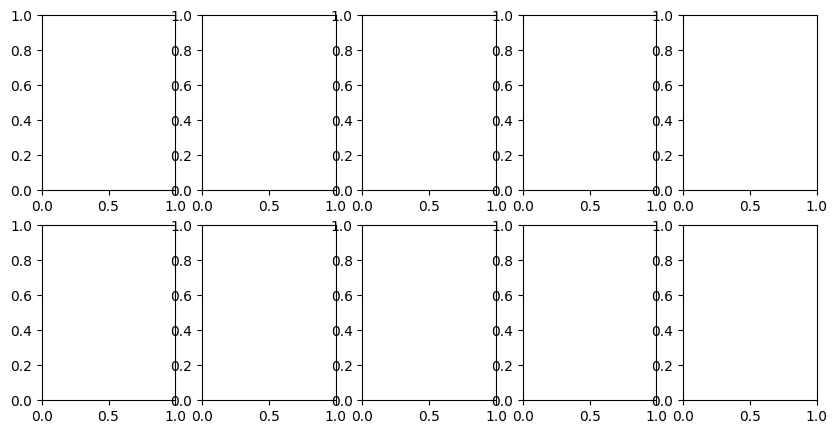

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))


In [8]:
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"Classe : {y[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Moyenne globale :", np.mean(X_scaled))
print("Écart-type global :", np.std(X_scaled))


Moyenne globale : 3.212665402365506e-18
Écart-type global : 0.9762812094883323


In [10]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

print("Dimensions avant ACP :", X_scaled.shape)
print("Dimensions après ACP :", X_pca_2.shape)

Dimensions avant ACP : (1797, 64)
Dimensions après ACP : (1797, 2)


In [11]:
print("Variance expliquée :")
print(pca_2.explained_variance_ratio_)

print("Variance expliquée cumulée :")
print(np.sum(pca_2.explained_variance_ratio_))

Variance expliquée :
[0.12033916 0.09561054]
Variance expliquée cumulée :
0.21594970500832794


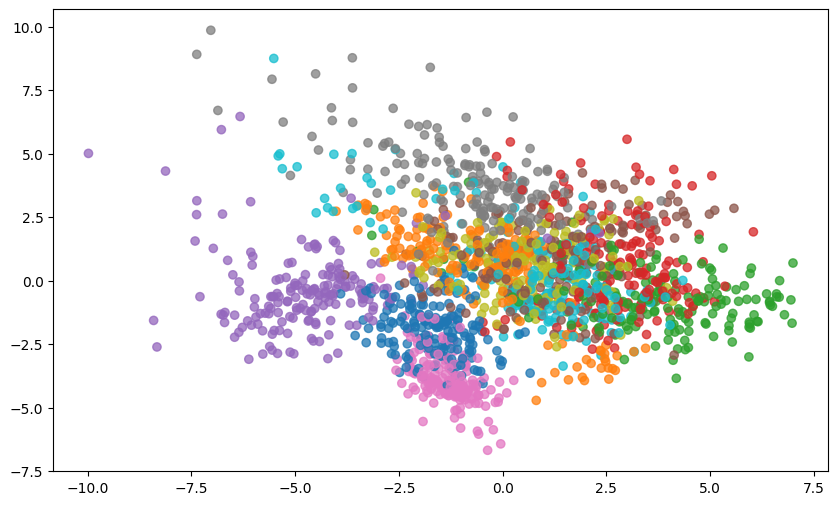

In [12]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca_2[:,0],
    X_pca_2[:,1],
    c=y,
    cmap='tab10',
    alpha=0.75
)

C:\Users\KOURAMOUDOU\AppData\Local\Temp\ipykernel_27304\2797427818.py:8: UserWarning: Adding colorbar to a different Figure <Figure size 1000x600 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter)


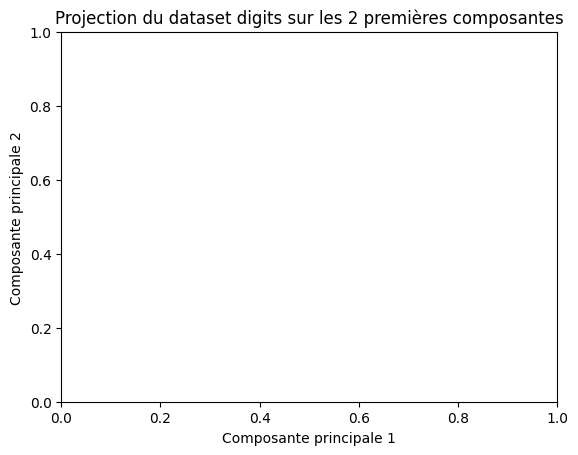

In [13]:
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

plt.title(
    "Projection du dataset digits sur les 2 premières composantes"
)

plt.colorbar(scatter)

plt.show()

In [14]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

variance_cumulee = np.cumsum(
    pca_full.explained_variance_ratio_
)

print(variance_cumulee)


[0.12033916 0.21594971 0.30039385 0.36537793 0.41397948 0.45612068
 0.49554151 0.52943532 0.55941753 0.58873755 0.61655561 0.64232616
 0.66507919 0.68735099 0.70900328 0.72814495 0.74590042 0.76228111
 0.77824572 0.79313763 0.80661732 0.81933664 0.83099501 0.84157148
 0.85132464 0.86077023 0.86940036 0.87776679 0.88574372 0.89320844
 0.90046426 0.90738337 0.91392246 0.92033038 0.92624422 0.93195585
 0.93719222 0.94201029 0.94654748 0.95077911 0.95483964 0.95881049
 0.96237542 0.9657833  0.96906165 0.97217197 0.97505772 0.97782262
 0.98041436 0.98275919 0.98494176 0.98697774 0.98893286 0.99076605
 0.99244551 0.99405787 0.9955355  0.99688668 0.99813769 0.99917465
 1.         1.         1.         1.        ]


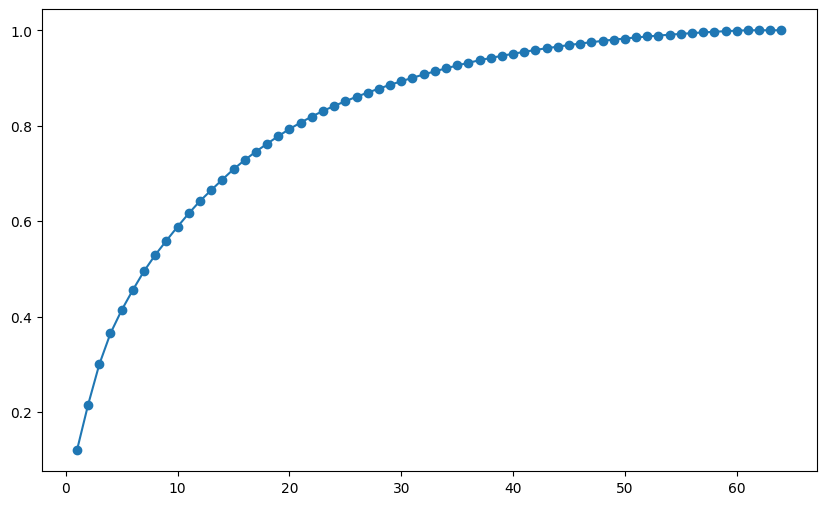

In [15]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(variance_cumulee)+1),
    variance_cumulee,
    marker='o'
)

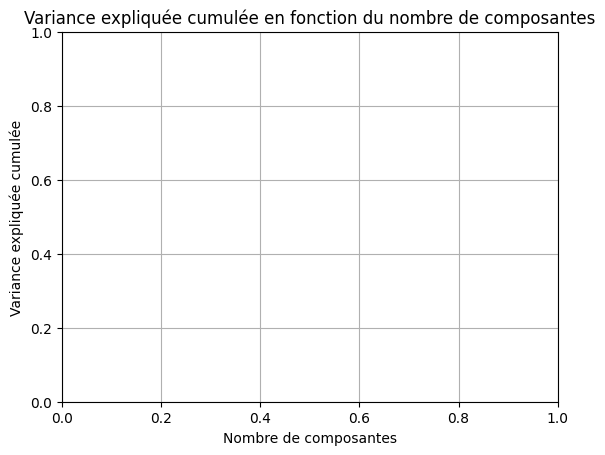

In [17]:
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")

plt.title(
    "Variance expliquée cumulée en fonction du nombre de composantes"
)

plt.grid(True)

plt.show()

In [18]:
n90 = np.argmax(variance_cumulee >= 0.90) + 1
n95 = np.argmax(variance_cumulee >= 0.95) + 1
n99 = np.argmax(variance_cumulee >= 0.99) + 1

print("90 % :", n90)
print("95 % :", n95)
print("99 % :", n99)

90 % : 31
95 % : 40
99 % : 54
